In [83]:
import sys
print(sys.executable)

/Users/sanulanawarathna/Documents/Vs Code/Finacial Forcasting using Time Series/.venv/bin/python


In [96]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import os
import datetime
from matplotlib import cm
from matplotlib.ticker import LinearLocator

In [85]:
# data = yf.download("AAPL", period="1y")
# plt.plot(data)
# data["Returns"] = data["Close"].pct_change()
# print(data[["Close", "Returns"]].head())
# data.to_csv("AAPL_data.csv")
data = pd.read_csv("appl.csv", parse_dates=True)
data = data.dropna()

## Testing Stationarity

ADF Statistic: -15.112920578526557
p-value: 7.650652461610084e-28
Critical Values: {'1%': np.float64(-3.456780859712), '5%': np.float64(-2.8731715065600003), '10%': np.float64(-2.572968544)}


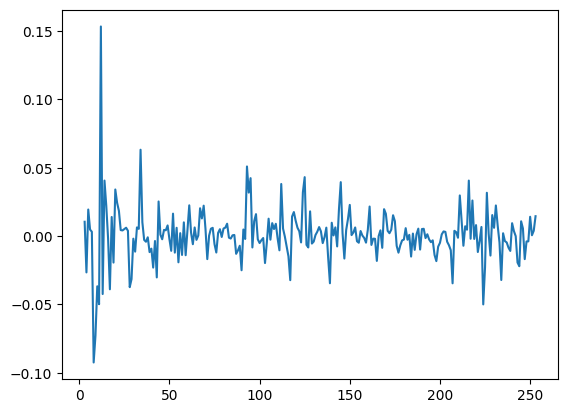

In [86]:
result = adfuller(data["Returns"])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])
plt.plot(data['Returns'])


## Realised Volatility 

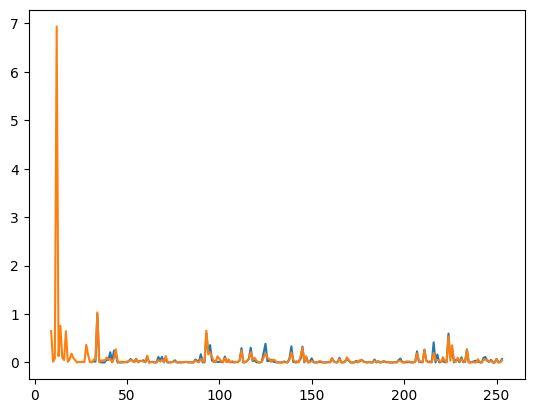

In [87]:
data['sq_dev_30'] = ( data['Returns']-data['Returns'].rolling(30).mean())**2*251
data['sq_dev_7'] = ( data['Returns']-data['Returns'].rolling(7).mean())**2*251
plt.plot(data['sq_dev_30'])
plt.plot(data['sq_dev_7'])


## Implied Volatility 

In [102]:
# ticker = yf.Ticker("AAPL")
# print(ticker.options)
# T_T_m = ticker.options

# S = 1
# K = 1
# r = 1
# T = 1
# sigma = 1
# x = T_T_m
# y = []
# z = []
# list_price = []


# for i in T_T_m:
#     chain = ticker.option_chain(i)
#     calls = chain.calls.copy()
#     price = calls['lastPrice'].values
#     list_price.append(price)
#     y.append(price.mean())
# def black_s(S,K,r,T,sigma):
#     d_1 = (np.log(S/K)+(r+(sigma**2/2))*T)/(sigma*T**0.5)
#     d_2 = d_1 - sigma*T**0.5

#     C_bs = S*(np.random.normal(d_1))-K*np.exp(-r*T)*(np.random.normal(d_2))
#     return C_bs

# for i in range(len(y)):
#     z.append(y[i]-black_s(S,K,r,T,sigma))

# x,y,z = np.array(x),np.array(y),np.array(z)


# fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# x, y= np.meshgrid(x,y)

# surf = ax.plot_surface(x, y, z, cmap=cm.coolwarm,
#                        linewidth=0, antialiased=False)

# plt.show()








## Implementing ARCH(1) model

[0,
 0,
 -0.582477008195533,
 0.42153179967146776,
 -6.852955322379738,
 3.4988888112265886,
 -16.97919429723566,
 -7.438944887344531,
 -82.24692555617021,
 -68.24444110113278,
 519.0731791025123,
 -0.011472390661968727,
 -666.7475242784653,
 -0.3029147524633425,
 2078.235480710078,
 -0.9784336133284431,
 -2918.381192645092,
 -0.7773335882852749,
 52802.816821898734,
 -9.294183658415562,
 -75605.5540753872,
 -33.2694049488569,
 -40264.074394260766,
 -316.55395500804343,
 65858.17314742644,
 -657.19608105342,
 28387.66165203729,
 3151.75937743931,
 -142398.23179790156,
 -0.23132431911881168,
 731700.3157095875,
 0.22528462710821745,
 133293.22765214564,
 2.1049003662629175,
 603137.2797465088,
 21.802979546593562,
 4603958.959792071,
 -8.696992541455511,
 7036365.887691842,
 -120.13709903215998,
 129822529.41811934,
 207.28326624343632,
 545884605.1573032,
 -733.16453477661,
 -3752822307.449195,
 -1495.8791418170158,
 27508972072.17449,
 11911.145139455883,
 -19467189566.339474,
 -11261

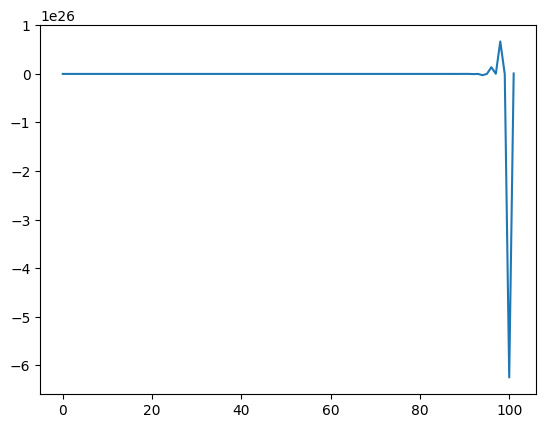

In [113]:
def arch_model(mew,alpha):
    y_t = [0]
    sigma_t = 0
    epsilon = [0]
    for i in range(100):
        z_t = np.random.normal(0,1)
        sigma_t = (alpha + np.random.randint(100)*epsilon[i-1]**2)**0.5
        epsilon.append(z_t*sigma_t)
    for x in epsilon:
        y_t.append(mew+x)
    plt.plot(y_t)
    plt.show
    return y_t
arch_model(0,1)

